In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11

windows = {
    "25%": "results/heldout_results_25.csv",
    "49%": "results/heldout_results_49.csv",
    "64%": "results/heldout_results_64.csv",
}

dfs = {}

for name, path in windows.items():
    dfs[name] = pd.read_csv(path)

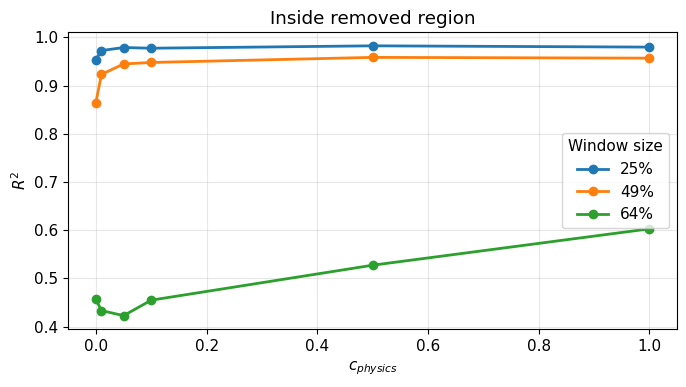

In [8]:
plt.figure()

for name, df in dfs.items():

    inside = (
        df[df["region"] == "inside_box"]
        .sort_values("c_physics")
    )

    plt.plot(
        inside["c_physics"],
        inside["R2_all"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.xlabel(r"$c_{physics}$")
plt.ylabel(r"$R^2$")
plt.title("Inside removed region")
plt.grid(alpha=0.3)
plt.legend(title="Window size")

plt.tight_layout()
plt.show()

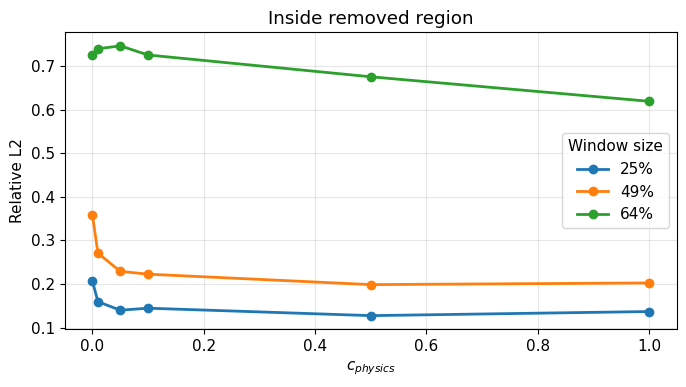

In [9]:
plt.figure()

for name, df in dfs.items():

    inside = (
        df[df["region"] == "inside_box"]
        .sort_values("c_physics")
    )

    plt.plot(
        inside["c_physics"],
        inside["RelL2_all"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.xlabel(r"$c_{physics}$")
plt.ylabel("Relative L2")
plt.title("Inside removed region")
plt.grid(alpha=0.3)
plt.legend(title="Window size")

plt.tight_layout()
plt.show()

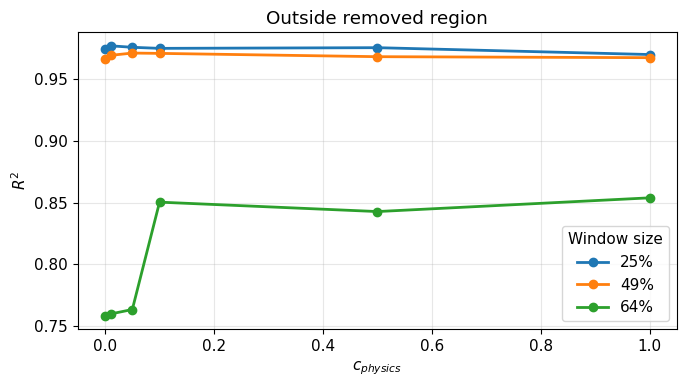

In [10]:
plt.figure()

for name, df in dfs.items():

    outside = (
        df[df["region"] == "outside_box"]
        .sort_values("c_physics")
    )

    plt.plot(
        outside["c_physics"],
        outside["R2_all"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.xlabel(r"$c_{physics}$")
plt.ylabel(r"$R^2$")
plt.title("Outside removed region")
plt.grid(alpha=0.3)
plt.legend(title="Window size")

plt.tight_layout()
plt.show()

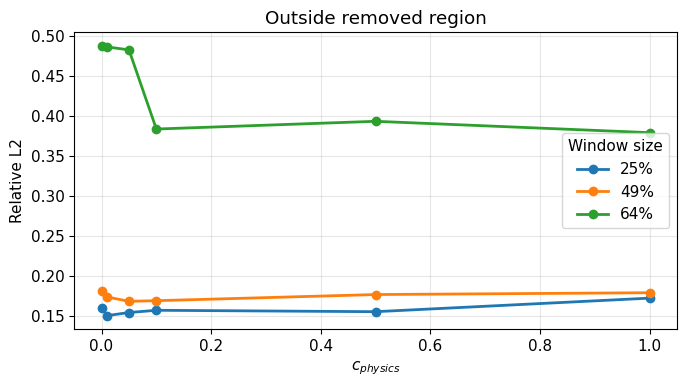

In [11]:
plt.figure()

for name, df in dfs.items():

    outside = (
        df[df["region"] == "outside_box"]
        .sort_values("c_physics")
    )

    plt.plot(
        outside["c_physics"],
        outside["RelL2_all"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.xlabel(r"$c_{physics}$")
plt.ylabel("Relative L2")
plt.title("Outside removed region")
plt.grid(alpha=0.3)
plt.legend(title="Window size")

plt.tight_layout()
plt.show()

In [14]:
heat = {}

for window, df in dfs.items():

    values = (
        df[df["region"] == "inside_box"]
        .sort_values("c_physics")
        .set_index("c_physics")["R2_all"]
    )

    heat[window] = values

heat = pd.DataFrame(heat).T

display(heat)

c_physics,0.00,0.01,0.05,0.10,0.50,1.00
25%,0.954160,0.972847,0.979122,0.977703,0.982665,0.980013
49%,0.864928,0.923224,0.945056,0.948126,0.958692,0.957087
64%,0.456512,0.433244,0.422724,0.454808,0.527370,0.602834


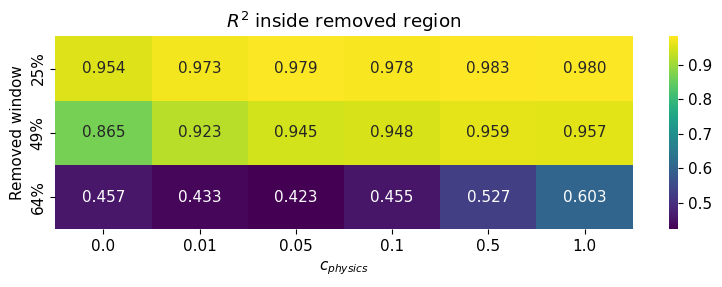

In [15]:
plt.figure(figsize=(8,3))

sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.xlabel(r"$c_{physics}$")
plt.ylabel("Removed window")
plt.title(r"$R^2$ inside removed region")

plt.tight_layout()
plt.show()